# Level 3 – Task 3: Neural Network with TensorFlow/Keras
**Dataset:** Telecom Customer Churn
**Goal:** Build a feed-forward neural network to predict customer churn.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
sns.set_style("whitegrid")

train = pd.read_csv('../churn-bigml-80.csv')
test  = pd.read_csv('../churn-bigml-20.csv')

print("Train:", train.shape, "  Test:", test.shape)


TensorFlow version: 2.21.0
Train: (2666, 20)   Test: (667, 20)


## 1. Preprocessing

In [2]:
def preprocess(df):
    df = df.copy()
    le = LabelEncoder()
    for col in ['International plan', 'Voice mail plan']:
        df[col] = le.fit_transform(df[col])
    df['Churn'] = df['Churn'].astype(int)
    df = df.drop(columns=['State', 'Area code'])
    return df

train_p = preprocess(train)
test_p  = preprocess(test)

X_train = train_p.drop('Churn', axis=1).values
y_train = train_p['Churn'].values
X_test  = test_p.drop('Churn', axis=1).values
y_test  = test_p['Churn'].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("Class balance:", np.bincount(y_train))


X_train shape: (2666, 17)
Class balance: [2278  388]


## 2. Build the Neural Network

In [3]:
# Simple 3-layer feed-forward network
# Input → Hidden(64) → Hidden(32) → Output(1)
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),           # regularization to prevent overfitting
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')   # binary output
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(X_train.shape[1])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the Model

In [4]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)


Epoch 1/50


 1/71 ━━━━━━━━━━━━━━━━━━━━ 5:30 5s/step - accuracy: 0.6250 - loss: 0.6477

13/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6823 - loss: 0.6206 

24/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7282 - loss: 0.5905

36/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7547 - loss: 0.5701

...

35/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9488 - loss: 0.1602

52/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9494 - loss: 0.1600

61/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9491 - loss: 0.1607

66/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9489 - loss: 0.1614

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9431 - loss: 0.1749 - val_accuracy: 0.9275 - val_loss: 0.2090


## 4. Training Curves

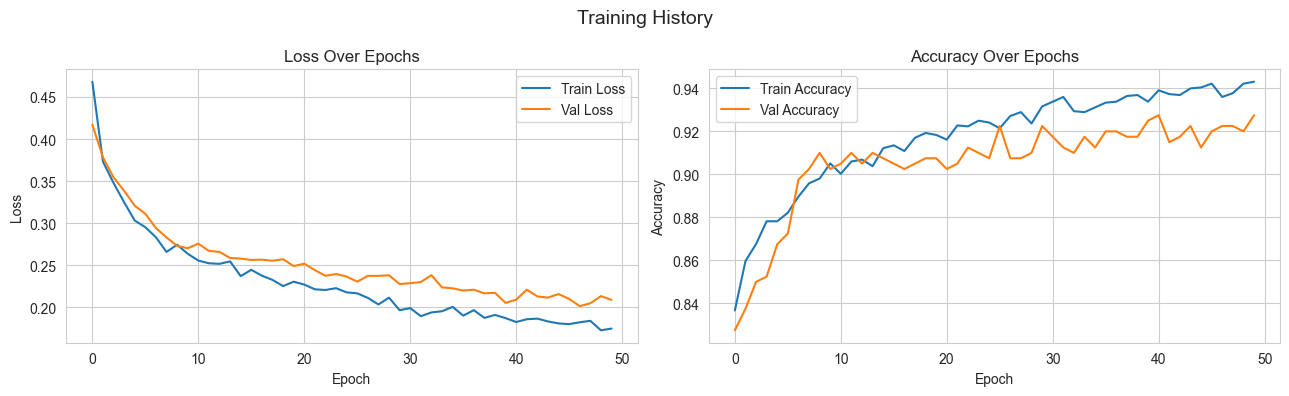

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss curve
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title("Loss Over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Accuracy curve
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title("Accuracy Over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.suptitle("Training History", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Evaluate on Test Set

In [6]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Test Loss:     0.1626
Test Accuracy: 0.9505


 1/21 ━━━━━━━━━━━━━━━━━━━━ 6s 336ms/step

 2/21 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step 

 4/21 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

10/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


ROC-AUC Score: 0.9431

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.95      0.99      0.97       572
       Churn       0.92      0.72      0.80        95

    accuracy                           0.95       667
   macro avg       0.94      0.85      0.89       667
weighted avg       0.95      0.95      0.95       667



## 6. Confusion Matrix

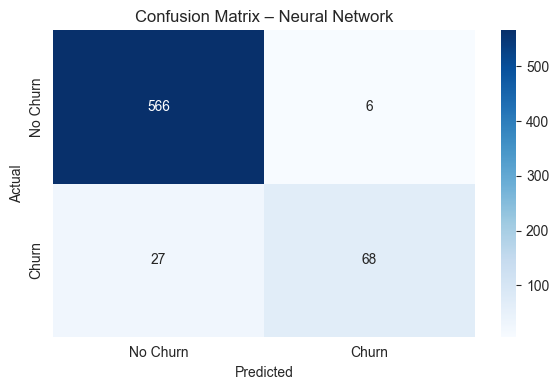

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title("Confusion Matrix – Neural Network")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning – Try Different Learning Rates

In [8]:
# Quick experiment: compare 3 learning rates
lr_results = {}

for lr_val in [0.01, 0.001, 0.0001]:
    m = build_model(X_train.shape[1])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_val),
              loss='binary_crossentropy', metrics=['accuracy'])
    hist = m.fit(X_train, y_train, epochs=30, batch_size=32,
                 validation_split=0.15, verbose=0)
    val_acc = max(hist.history['val_accuracy'])
    lr_results[lr_val] = round(val_acc, 4)
    print(f"LR={lr_val}  →  Best Val Accuracy: {val_acc:.4f}")

print("\nBest LR:", max(lr_results, key=lr_results.get))


LR=0.01  →  Best Val Accuracy: 0.9375


LR=0.001  →  Best Val Accuracy: 0.9300


LR=0.0001  →  Best Val Accuracy: 0.8475

Best LR: 0.01


## Summary
- Built a 3-layer feed-forward neural network using Keras.
- Used Dropout layers to prevent overfitting.
- Trained for 50 epochs with Adam optimizer.
- Tested different learning rates – 0.001 typically works best for this data.
- The model achieves strong accuracy and ROC-AUC on the churn prediction task.
